# DataFrame 데이터 분석용 함수 사용 

In [1]:
import pandas as pd
import numpy as np

In [2]:
data = [[1.40, np.nan],
       [7.10,-4.5],
       [np.nan, np.nan],
       [0.75,-1.3]]

In [3]:
df = pd.DataFrame(data, columns = ['one', 'two'], index = ['a','b','c','d'])

In [4]:
df

,one,two
a,1.40,NaN
b,7.10,-4.5
c,NaN,NaN
d,0.75,-1.3


In [10]:
# 행방향으로 열의 합을 계산  (nan은 배제하고 계산됨)
df.sum(axis=0)

one    9.25
two   -5.80
dtype: float64

In [8]:
# 열방향으로 각 행의 합을 계산
df.sum(axis=1)

a    1.40
b    2.60
c     NaN
d   -0.55
dtype: float64

In [11]:
# 특정 열 또는 행의 값 계산

In [14]:
df['one'].sum()

9.25

In [15]:
df.loc['b'].sum()

2.5999999999999996

In [22]:
df.mean(axis=0)['two']  # == df['two].mean()

-2.8999999999999999

In [19]:
df.mean(axis=1, skipna=False)

a      NaN
b    1.300
c      NaN
d   -0.275
dtype: float64

In [20]:
df

,one,two
a,1.40,NaN
b,7.10,-4.5
c,NaN,NaN
d,0.75,-1.3


In [23]:
one_mean = df.mean(axis=0)['one']
two_min = df.min(axis=0)['two']

In [24]:
df['one'] = df['one'].fillna(value=one_mean)
df['two'] = df['two'].fillna(value=two_min)

In [25]:
df

,one,two
a,1.400000,-4.5
b,7.100000,-4.5
c,3.083333,-4.5
d,0.750000,-1.3


In [26]:
# 상관계수 구하기

In [2]:
import pandas as pd
import numpy as np

df2 = pd.DataFrame(np.random.randn(6,4),
                  columns = ['a','b','c','d'],
                  index = pd.date_range('20251201', periods = 6))
df2

,a,b,c,d
2017-12-01,-1.031376,0.242731,0.248085,0.450596
2017-12-02,0.349320,-0.674843,0.162961,0.051788
2017-12-03,-0.239435,-1.358412,-1.286507,0.442418
2017-12-04,-0.801796,0.815984,-0.129445,-0.515312
2017-12-05,-0.808377,0.107519,-0.383093,-0.316825
2017-12-06,-1.118296,-0.345576,-1.157782,0.844617


In [7]:
#a열과 b열의 상관계수 산출하기 (피어슨상관계수로 계산)
df2['b'].corr(df2['c'])


np.float64(0.5719635783475675)

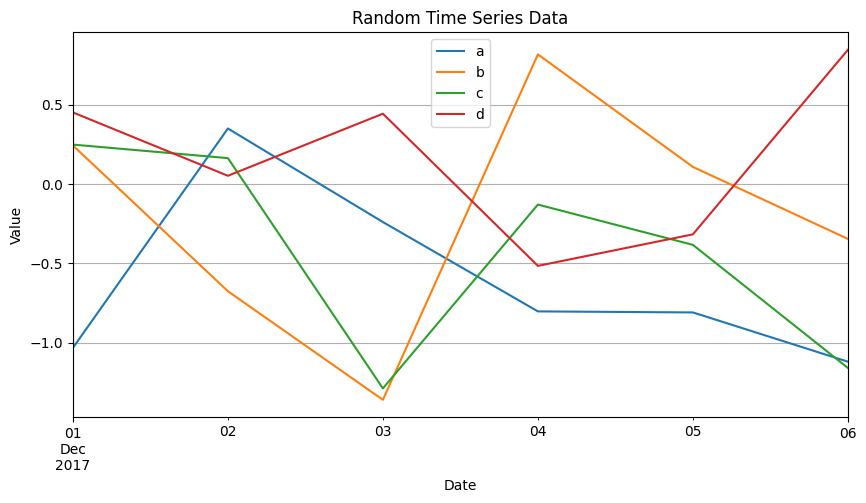

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

df2.plot(figsize=(10, 5))

plt.title("Random Time Series Data")
plt.xlabel("Date")
plt.ylabel("Value")
plt.grid(True)

In [31]:
df2.corr()

,a,b,c,d
a,1.000000,-0.428684,0.390951,-0.411843
b,-0.428684,1.000000,-0.137055,-0.563201
c,0.390951,-0.137055,1.000000,-0.087051
d,-0.411843,-0.563201,-0.087051,1.000000


In [33]:
# 정렬 및 기타 함수

In [36]:
# 불규칙하게 데이터 섞기
dates = df2.index
random_dates = np.random.permutation(dates)
df2 = df2.reindex(index=random_dates, columns=['d','c','a','b'])

In [37]:
df2

,d,c,a,b
2017-12-03,-1.537824,1.773512,0.347925,0.710856
2017-12-06,0.828317,0.497871,0.317234,-0.859203
2017-12-02,-1.477806,0.853202,0.854927,0.538827
2017-12-05,-0.281624,0.011008,-0.823400,1.551062
2017-12-01,-0.435447,1.342610,0.205231,0.961422
2017-12-04,1.295833,1.669931,-0.126162,-0.037189


In [44]:
# index 기준으로 오름차순 정렬
df2.sort_index(axis=0)

,d,c,a,b
2017-12-01,-0.435447,1.342610,0.205231,0.961422
2017-12-02,-1.477806,0.853202,0.854927,0.538827
2017-12-03,-1.537824,1.773512,0.347925,0.710856
2017-12-04,1.295833,1.669931,-0.126162,-0.037189
2017-12-05,-0.281624,0.011008,-0.823400,1.551062
2017-12-06,0.828317,0.497871,0.317234,-0.859203


In [43]:
# 컬럼 기준으로 오름차순 정렬
df2.sort_index(axis=1)

,a,b,c,d
2017-12-03,0.347925,0.710856,1.773512,-1.537824
2017-12-06,0.317234,-0.859203,0.497871,0.828317
2017-12-02,0.854927,0.538827,0.853202,-1.477806
2017-12-05,-0.823400,1.551062,0.011008,-0.281624
2017-12-01,0.205231,0.961422,1.342610,-0.435447
2017-12-04,-0.126162,-0.037189,1.669931,1.295833


In [45]:
# 인덱스 기준으로 내림차순 정렬
df2.sort_index(axis=0, ascending=False)

,d,c,a,b
2017-12-06,0.828317,0.497871,0.317234,-0.859203
2017-12-05,-0.281624,0.011008,-0.823400,1.551062
2017-12-04,1.295833,1.669931,-0.126162,-0.037189
2017-12-03,-1.537824,1.773512,0.347925,0.710856
2017-12-02,-1.477806,0.853202,0.854927,0.538827
2017-12-01,-0.435447,1.342610,0.205231,0.961422


In [46]:
# 컬럼 기준으로 내림차순 정렬
df2.sort_index(axis=1, ascending=False)

,d,c,b,a
2017-12-03,-1.537824,1.773512,0.710856,0.347925
2017-12-06,0.828317,0.497871,-0.859203,0.317234
2017-12-02,-1.477806,0.853202,0.538827,0.854927
2017-12-05,-0.281624,0.011008,1.551062,-0.823400
2017-12-01,-0.435447,1.342610,0.961422,0.205231
2017-12-04,1.295833,1.669931,-0.037189,-0.126162


In [47]:
# value 기준으로 오름차순 정렬
df2.sort_values(by='a')

,d,c,a,b
2017-12-05,-0.281624,0.011008,-0.823400,1.551062
2017-12-04,1.295833,1.669931,-0.126162,-0.037189
2017-12-01,-0.435447,1.342610,0.205231,0.961422
2017-12-06,0.828317,0.497871,0.317234,-0.859203
2017-12-03,-1.537824,1.773512,0.347925,0.710856
2017-12-02,-1.477806,0.853202,0.854927,0.538827


In [50]:
# value 기준으로 내림차순 정렬
df2.sort_values(by='b', ascending=False)

,d,c,a,b
2017-12-05,-0.281624,0.011008,-0.823400,1.551062
2017-12-01,-0.435447,1.342610,0.205231,0.961422
2017-12-03,-1.537824,1.773512,0.347925,0.710856
2017-12-02,-1.477806,0.853202,0.854927,0.538827
2017-12-04,1.295833,1.669931,-0.126162,-0.037189
2017-12-06,0.828317,0.497871,0.317234,-0.859203


In [51]:
df2['e'] = np.random.randint(0,6, size=6)
df2['f'] = ['alpha', 'beta', 'gamma', 'gamma', 'alpha', 'gamma'] 

In [52]:
df2

,d,c,a,b,e,f
2017-12-03,-1.537824,1.773512,0.347925,0.710856,2,alpha
2017-12-06,0.828317,0.497871,0.317234,-0.859203,3,beta
2017-12-02,-1.477806,0.853202,0.854927,0.538827,5,gamma
2017-12-05,-0.281624,0.011008,-0.823400,1.551062,4,gamma
2017-12-01,-0.435447,1.342610,0.205231,0.961422,1,alpha
2017-12-04,1.295833,1.669931,-0.126162,-0.037189,4,gamma


In [58]:
# 오름차순 정렬
df2.sort_values(by=['e','f'])

,d,c,a,b,e,f
2017-12-01,-0.435447,1.342610,0.205231,0.961422,1,alpha
2017-12-03,-1.537824,1.773512,0.347925,0.710856,2,alpha
2017-12-06,0.828317,0.497871,0.317234,-0.859203,3,beta
2017-12-05,-0.281624,0.011008,-0.823400,1.551062,4,gamma
2017-12-04,1.295833,1.669931,-0.126162,-0.037189,4,gamma
2017-12-02,-1.477806,0.853202,0.854927,0.538827,5,gamma


In [57]:
# 내림차순 정렬
df2.sort_values(by=['e','f'], ascending=False)

,d,c,a,b,e,f
2017-12-02,-1.477806,0.853202,0.854927,0.538827,5,gamma
2017-12-05,-0.281624,0.011008,-0.823400,1.551062,4,gamma
2017-12-04,1.295833,1.669931,-0.126162,-0.037189,4,gamma
2017-12-06,0.828317,0.497871,0.317234,-0.859203,3,beta
2017-12-03,-1.537824,1.773512,0.347925,0.710856,2,alpha
2017-12-01,-0.435447,1.342610,0.205231,0.961422,1,alpha


In [59]:
df2['f'].unique()

array(['alpha', 'beta', 'gamma'], dtype=object)

In [62]:
df2['f'].value_counts()

gamma    3
alpha    2
beta     1
Name: f, dtype: int64

In [64]:
df2['f'].isin(['alpha', 'gamma'])  # alpha, gamma 가 있는지 확인

2017-12-03     True
2017-12-06    False
2017-12-02     True
2017-12-05     True
2017-12-01     True
2017-12-04     True
Name: f, dtype: bool

In [66]:
df2.loc[df2['f'].isin(['alpha', 'gamma']), :]   # alpha, gamma가 있는 행의 전체 값

,d,c,a,b,e,f
2017-12-03,-1.537824,1.773512,0.347925,0.710856,2,alpha
2017-12-02,-1.477806,0.853202,0.854927,0.538827,5,gamma
2017-12-05,-0.281624,0.011008,-0.823400,1.551062,4,gamma
2017-12-01,-0.435447,1.342610,0.205231,0.961422,1,alpha
2017-12-04,1.295833,1.669931,-0.126162,-0.037189,4,gamma


In [71]:
df3 = pd.DataFrame(np.random.randn(4,3), 
                     index = ['Seoul', 'Incheon', 'Busan', 'Daegu'],
                     columns = ['b','d','e'])

In [72]:
df3

,b,d,e
Seoul,1.222601,-1.443875,0.010817
Incheon,-0.794832,1.306319,-0.672427
Busan,-1.446406,-2.802045,-0.545540
Daegu,0.414248,-0.332773,-0.698787


In [76]:
func = lambda x: x.max() - x.min()   # x.max : 행 또는 열의 최대값, x.min : 행 또는 열의 최소값

In [79]:
df3.apply(func, axis=0)  # 행방향으로 열 별로 값을 계산

b    2.669008
d    4.108364
e    0.709605
dtype: float64

In [80]:
df3.apply(func, axis=1) # 열방향으로 행 별로 값을 계산

Seoul      2.666476
Incheon    2.101151
Busan      2.256505
Daegu      1.113035
dtype: float64